# Hubble Constant Estimation

The provided dataset contains results of a simulated observational campaign surveying galaxy spectra and Cepheid variable stars. For Cepheid variables, the period-luminosity relation is established as:

$$M = -2.43 \cdot (\log_{10}(P) - 1) - 4.05$$

The dataset contains measured spectra of several galaxies and photometric information about Cepheid variables in these galaxies, where available. There is at most one Cepheid per galaxy. Analysis of the measured spectra verified that the observed spectra contain only lines that were observed in the laboratory reference spectrum.

Use the provided dataset to determine Hubble's constant, incorporating all available data. Apply unweighted linear regression with the intercept fixed at the origin, consistent with the physical expectation that recession velocity vanishes at zero distance. Assume the relativistic Doppler formula for computing velocities from redshifts.

For redshift extraction, identify observed spectral lines with the lines in the laboratory reference spectrum. Estimate the redshift from the line with the largest laboratory wavelength present in the observed spectrum to minimize reading error. Assume that the brightness profile of each line can be modelled by a normal distribution, with the wavelength of the line corresponding to the mean of the distribution.

Produce the following outputs:

1. A PDF file containing a list of only those galaxies for which a spectroscopic measurement exists in the dataset and which also have a Cepheid variable allowing their distance to be determined. The list should state the redshift of each galaxy and be ordered by galaxy ID.
2. A scatter plot in a PNG file showing the recession velocity of each galaxy as a function of the distance estimated from its Cepheid variable. The plot should include a physically motivated fit of Hubble's law, with the fitted equation stated quantitatively.
3. A TXT file with a clearly stated value of Hubble's constant from this dataset, including the statistical uncertainty.

Import necessary dependencies used in the data generation and data processing pipeline.

In [32]:
import numpy as np
import random
import pandas as pd
import string
import math
import matplotlib.pyplot as plt
import os
import shutil
from matplotlib.ticker import MultipleLocator, FuncFormatter
from scipy.stats import linregress
from matplotlib.backends.backend_pdf import PdfPages

This is where you can set all the parameters of the simulation and data generation.

- **N_GALAXIES** : Number of galaxies to generate in the table
- **Z_MAX** : Maximal value of the redshift in the dataset
- **SIGMA_DISTANCE_CEPHEID** : Introduces spread in the distances of Cepheids. We don't want all datapoints be exactly on the line $v = H_0 d$
- **CEPHEID_GENERATE_PROBABILITY** : Not all generated galaxies in the table have Cepheid. This is the probability that galaxy entry has also Cepheid entry.
- **GALAXY_GENERATE_PROBABILITY** : Not all galaxies have measured spectra. This influences how many observed spectra images we will have (~ N_GALAXIES * SPECTRUM_GENERATE_PROBABILITY)

In [33]:
#Path to save outputs
path = "./"
os.chdir(path)
spectra_folder = 'input_data/observed_spectra'
shutil.rmtree(spectra_folder)
os.makedirs(spectra_folder)

# Random seed
SEED = np.random.randint(0, 1000000) # Use a random seed for each run
# SEED = 42 # Use this to make the generation reproducible
random.seed(SEED)

# Physics constants
c = 299792.458 #km/s
H = 67

#Simulation parameters
N_GALAXIES = 10
SIGMA_DISTANCE_CEPHEIDES = 0.1
Z_MAX = 0.05
CEPHEID_GENERATE_PROBABILITY = 1
GALAXY_GENERATE_PROBABILITY = 1

# Laboratory spectrum
LAMBDA_MIN = 400.0  # nm
LAMBDA_MAX = 750.0  # nm
LAB_SPECTRUM = {656.3: 1.0, 500.7: 0.9, 589.0: 0.85, 589.6: 0.8, 486.1: 0.75, 495.9: 0.65, 
                587.6: 0.6, 658.3: 0.55, 654.8: 0.5, 434.0: 0.45, 671.6: 0.38, 673.1: 0.34, 
                410.2: 0.3, 667.8: 0.27, 630.0: 0.23, 518.4: 0.2, 447.1: 0.17, 422.7: 0.15, 
                636.4: 0.12, 438.3: 0.1}

Data generation pipeline.

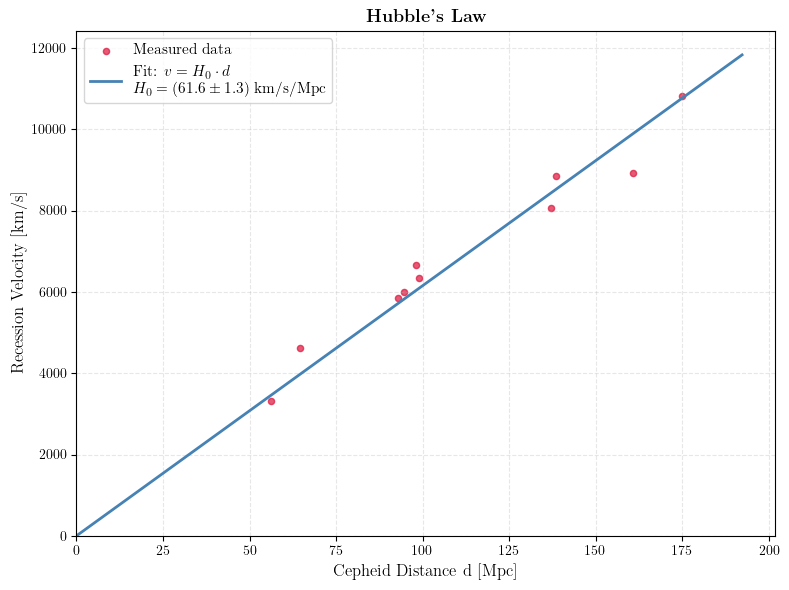

In [ ]:
############################################################
################ Dataframe format
############################################################

df = pd.DataFrame({ 'index': pd.Series(dtype='int'),
                    'galaxy_ID': pd.Series(dtype='str'),
                    'z' : pd.Series(dtype='float'),
                    'spectrum' : pd.Series(dtype='object'),
                    'true_distance [pc]' : pd.Series(dtype='float'),
                    'cepheid_ID': pd.Series(dtype='str'),
                    'cepheid_distance [pc]' : pd.Series(dtype='float'),
                    'mean_mag_cepheid': pd.Series(dtype='float'),
                    'period [days]': pd.Series(dtype='float'),})


############################################################
################ Function to produce graphical spectra
############################################################

def plot_spectrum(input_spectrum : dict[float, float], title: str = '', 
                  name : str = '', save_to: str = path) -> None:
    def gaussian(x, mu, sigma, amplitude):
        return amplitude * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))

    wavelength = np.linspace(LAMBDA_MIN, LAMBDA_MAX, 7000)
    intensity = np.zeros_like(wavelength)
    for mu, amp in input_spectrum.items():
        intensity += gaussian(wavelength, mu, sigma=0.1, amplitude=amp)
    intensity /= intensity.max()

    image = np.tile(intensity, (80, 1))

    fig, ax = plt.subplots(figsize=(14, 2))
    ax.imshow(image, cmap='gray', aspect='auto', extent=[wavelength[0], wavelength[-1], 0, 1])
    ax.set_title(f"{title}")
    ax.set_yticks([])
    ax.set_xlabel("Wavelength (nm)")

    # Major ticks every 10 nm (longer)
    ax.xaxis.set_major_locator(MultipleLocator(10))
    # Minor ticks every 1 nm (shorter)
    ax.xaxis.set_minor_locator(MultipleLocator(1))

    # Set tick lengths
    ax.tick_params(axis='x', which='major', length=8)
    ax.tick_params(axis='x', which='minor', length=4)

    # Labels only at multiples of 50 using FuncFormatter
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x)}' if x % 50 == 0 else ''))

    plt.tight_layout()
    plt.savefig(f"{save_to}/{name}.png", dpi=150, bbox_inches="tight")
    plt.close()
    #plt.show()

plot_spectrum(LAB_SPECTRUM, f'Spectrum from the laboratory ({int(LAMBDA_MIN)} - {int(LAMBDA_MAX)} nm)', "spectral_lines_lab", save_to=path + "/input_data")


############################################################
################ Loop for the data generation
############################################################

for i in range(N_GALAXIES):
    index = i
    galaxy_ID = 'GID' + ''.join(random.choices(string.digits, k=6))

    if np.random.uniform(0,1) < GALAXY_GENERATE_PROBABILITY:
        z = random.uniform(0.2,1)*Z_MAX
        LINE_VISIBLE_PROBABILITY = 0.5
        spectrum = {}
        for line in LAB_SPECTRUM.keys():
            shifted_line = line * (z + 1)
            if random.uniform(0,1) < LINE_VISIBLE_PROBABILITY:
                spectrum[shifted_line] = LAB_SPECTRUM[line]
        plot_spectrum(spectrum, f"Observed spectrum - {galaxy_ID}", galaxy_ID, path + spectra_folder)
    else:
        z = np.nan
        spectrum = {}

    true_distance = float(z*c/H * 10**6)
    if np.random.uniform(0,1) < CEPHEID_GENERATE_PROBABILITY and not np.isnan(z):
        cepheid_ID = 'HDD' + ''.join(random.choices(string.digits, k=6))
        cepheid_distance = np.random.normal(loc=true_distance, scale=true_distance*SIGMA_DISTANCE_CEPHEIDES) #pc
        period = abs(np.random.normal(loc=60, scale=20))
        mean_mag = -2.43*(math.log10(period) - 1) - 4.05 - 5 + 5*math.log10(cepheid_distance)
    else:
        cepheid_ID = np.nan
        cepheid_distance = np.nan
        period = np.nan
        mean_mag = np.nan

    new_row = pd.DataFrame([{'index' : index,
                             'galaxy_ID' : galaxy_ID,
                             'z' : z,
                             'spectrum' : spectrum,
                             'true_distance [pc]' : true_distance,
                             'cepheid_ID' : cepheid_ID,
                             'cepheid_distance [pc]' : cepheid_distance,
                             'mean_mag_cepheid' : mean_mag,
                             'period [days]' : period}])
    df = pd.concat([df, new_row], ignore_index=True)

#Print data that can be estimated
df_est = df.copy()
df_est['z'] = df['z'].round(4)
df_est['mean_mag_cepheid'] = df['mean_mag_cepheid'].round(3)
df_est['period [days]'] = df['period [days]'].round(4)

#Print cepheides to .csv file
df_out = df_est.copy()
df_out['mean_mag_cepheid'] = df_est['mean_mag_cepheid'].map('{:.3f}'.format)
df_out['period [days]'] = df_est['period [days]'].map('{:.4f}'.format)
df_out[['galaxy_ID' , 'cepheid_ID', 'mean_mag_cepheid', 'period [days]']].to_csv(path + "/input_data/cepheides_mesurements.csv", index=False)


############################################################
################ Output estimated redshifts pdf - solution
############################################################

df_filtered = df_out.loc[df_out['z'].notna() & df_out['cepheid_ID'].notna()].copy()
df_filtered.sort_values(by='galaxy_ID', ascending=True, inplace=True)
df_out_pdf = df_filtered[['galaxy_ID', 'z']].reset_index(drop=True)

with PdfPages(path + "./golden_truth/redshifts.pdf") as pdf:
    fig, ax = plt.subplots(figsize=(6, len(df_out_pdf) * 0.3 + 1))
    ax.axis('off')
    table = ax.table(
        cellText=df_out_pdf.values,
        colLabels=df_out_pdf.columns,
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(True)
    table.scale(1, 1.4)
    for (row, col), cell in table.get_celld().items():
        if row == 0:  # header row
            cell.set_text_props(fontweight='bold')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()


############################################################
### Plot the "Hubble law", do the fit and output requested 
### TXT file- solution
############################################################

def plot_hubble(df: pd.DataFrame) -> None:
    plt.rcParams['text.usetex'] = True
    plt.rcParams['font.family'] = 'serif'
    mask = df['cepheid_distance [pc]'].notna() & df['z'].notna()
    x = df.loc[mask, 'cepheid_distance [pc]'] / 1e6
    y = c * ((df.loc[mask, 'z'] + 1)**2 -1)/((df.loc[mask, 'z'] + 1)**2 + 1)

    # Fit through zero (because v = H_0*d) and its standard error
    H0        = np.sum(x * y) / np.sum(x ** 2)
    residuals = y - H0 * x
    H0_err    = np.sqrt(np.sum(residuals ** 2) / ((len(x) - 1) * np.sum(x ** 2)))

    x_fit = np.linspace(0, x.max() * 1.1, 200)
    y_fit = H0 * x_fit

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(x, y, s=20, alpha=0.7, color='crimson', label='Measured data')
    ax.plot(x_fit, y_fit, color='steelblue', lw=2,
            label=f'Fit: $v = H_0 \\cdot d$\n$H_0 = ({H0:.1f} \\pm {H0_err:.1f})$ km/s/Mpc')

    # Write the estimated Hubble's constant to a text file
    with open(path + './golden_truth/hubbles_constant.txt', 'w') as f:
        print(f"The Hubble's constant estimated from the presented dataset is {H0:.1f} ± 
              {H0_err:.1f} km/s/Mpc.", file=f)

    ax.set_xlabel('Cepheid Distance d [Mpc]', fontsize=12)
    ax.set_ylabel('Recession Velocity [km/s]', fontsize=12)
    ax.set_title('\\textbf{Hubble\'s Law}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlim(0, None)
    ax.set_ylim(0, None)

    plt.tight_layout()
    plt.savefig(path + './golden_truth/hubble_law.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_hubble(df_est)

Save the dataframe with intermediate results for future inspection.

In [35]:
# Save dataframe for potential further analysis
df.to_pickle("./golden_truth/dataframe.pkl")